# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AA05478

Name: Rishabh Jain

Email: 2025aa05478@wilp.bits-pilani.ac.in

Date: 2nd Feb 2025

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split#, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from collections import Counter, defaultdict




In [2]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2

#Set random seed for reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

#set device
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

### 1.1 Dataset Selection and Loading

TODO: Load your chosen dataset

In [3]:

#  REQUIRED: Fill in these metadata fields
dataset_name = "Plant Disease Detection"
dataset_source = "kaggle: https://www.kaggle.com/code/vad13irt/plant-disease-classification/input"
train_data_path = "/Users/rishabhjain/Desktop/archive/train" 
batch_size=16
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),   # converts to [0,1] and CHW
])

train_dataset = ImageFolder(
    root=train_data_path,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=False
)
class_counts = Counter(train_dataset.targets)

sample_image, _ = train_dataset[0]
image_shape = list(sample_image.shape)  
print("Total images:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

# REQUIRED: Fill in these metadata fields
n_samples = len(train_dataset)  # TODO: Total number of images
n_classes = len(train_dataset.classes)  # TODO: Number of classes
min_samples = min(class_counts.values())
max_samples = max(class_counts.values())
avg_samples = sum(class_counts.values()) / len(class_counts)

samples_per_class = f"min: {min_samples}, max: {max_samples}, avg: {avg_samples:.2f}"
image_shape = [image_shape[1], image_shape[2], image_shape[0]]  # [height, width, channels]
problem_type = "classification"

Total images: 1532
Classes: ['Healthy', 'Powdery', 'Rust']
Number of classes: 3


In [4]:
# Primary metric selection
primary_metric = "Accuracy"
metric_justification = """
Accuracy is chosen as the primary evaluation metric for plant disease detection because 
the dataset is balanced across disease classes, the cost of misclassification is similar
across categories, and the task involves multi-class classification where overall correctness
is important. Precision, recall, and confusion matrix are additionally reported to analyze
disease-specific performance and ensure reliable detection."""

In [5]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Plant Disease Detection
Source: kaggle: https://www.kaggle.com/code/vad13irt/plant-disease-classification/input
Total Samples: 1532
Number of Classes: 3
Samples per Class: min: 500, max: 528, avg: 510.67
Image Shape: [224, 224, 3]
Primary Metric: Accuracy
Metric Justification: 
Accuracy is chosen as the primary evaluation metric for plant disease detection because 
the dataset is balanced across disease classes, the cost of misclassification is similar
across categories, and the task involves multi-class classification where overall correctness
is important. Precision, recall, and confusion matrix are additionally reported to analyze
disease-specific performance and ensure reliable detection.


### 1.2 Data Exploration and Visualization

- TODO: Show sample images from each class
- TODO: Plot class distribution
- TODO: Display image statistics

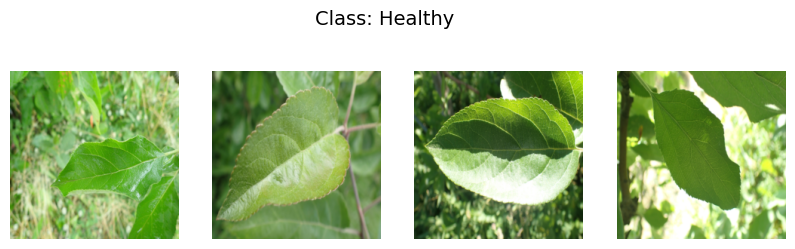

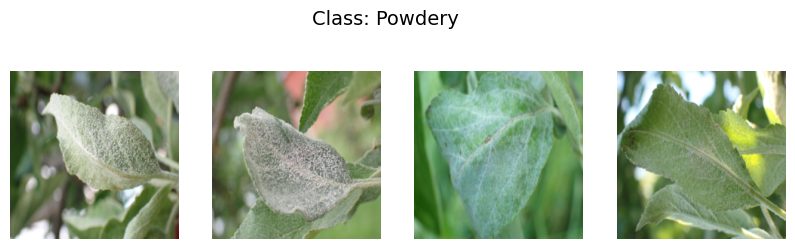

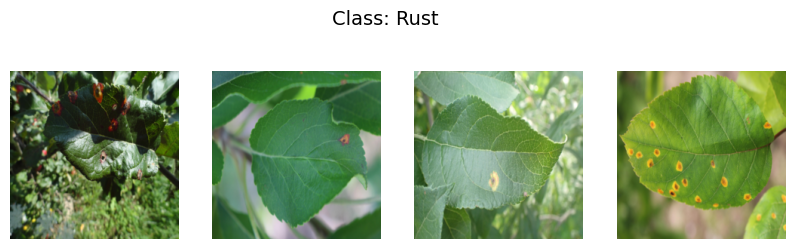

In [6]:

images_per_class = 4

# Group images by class
class_images = defaultdict(list)
for img, label in train_dataset:
    class_name = train_dataset.classes[label]
    if len(class_images[class_name]) < images_per_class:
        class_images[class_name].append(img)

# Plot
for class_name, images in class_images.items():
    plt.figure(figsize=(10, 3))
    for i, img in enumerate(images):
        # Convert tensor [C, H, W] → [H, W, C]
        img_np = img.permute(1, 2, 0).numpy()
        plt.subplot(1, images_per_class, i + 1)
        plt.imshow(img_np)
        #plt.title(class_name)
        plt.axis("off")
    plt.suptitle(f"Class: {class_name}", fontsize=14)
    plt.show()


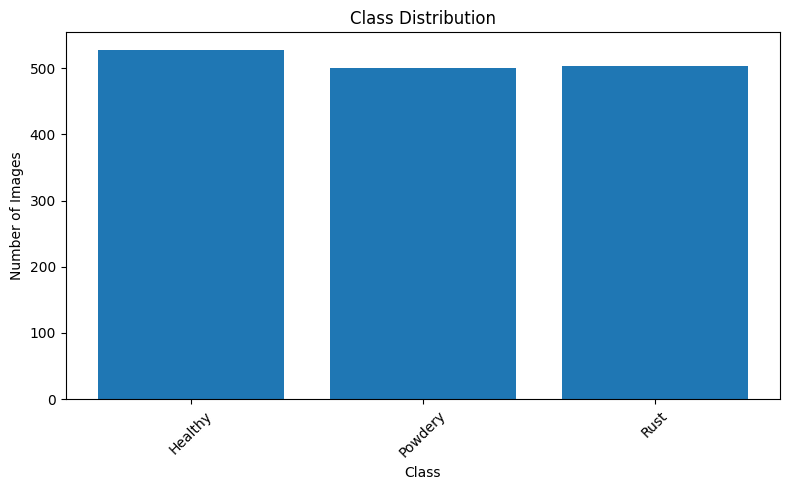

In [7]:
# Extract labels
labels = train_dataset.targets 

# Count samples per class
class_counts = Counter(labels)

class_names = train_dataset.classes
counts = [class_counts[i] for i in range(len(class_names))]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Analyze image dimensions
heights = []
widths = []
channels = []

for img, _ in train_dataset:
    c, h, w = img.shape
    heights.append(h)
    widths.append(w)
    channels.append(c)

print("Image Height  -> min:", min(heights), "max:", max(heights), "mean:", sum(heights)/len(heights))
print("Image Width   -> min:", min(widths),  "max:", max(widths),  "mean:", sum(widths)/len(widths))
print("Image Channels-> unique:", set(channels))


Image Height  -> min: 224 max: 224 mean: 224.0
Image Width   -> min: 224 max: 224 mean: 224.0
Image Channels-> unique: {3}


### 1.3 Data Preprocessing
- TODO: Resize images to consistent size
- TODO: Normalize pixel values
- TODO: Split into train/test (90/10 or 85/15)

In [9]:
# Images are normalized to [0,1] range using torchvision.transforms.ToTensor()

from torch.utils.data import random_split

train_test_ratio = "90/10"
split_ratio = 0.9

train_size = int(len(train_dataset) * split_ratio)
test_size  = len(train_dataset) - train_size

train_data, test_data = random_split(
    train_dataset,
    [train_size, test_size]
)

train_samples = len(train_data)
test_samples = len(test_data)

batch_size = 16

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=False
)
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)   # [B, 3, H, W]
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Image dtype: torch.float32


In [10]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90/10
Training Samples: 1378
Test Samples: 154


### 2.1 Custom CNN Architecture Design
- TODO: Define your CNN architecture
- TODO: Ensure Global Average Pooling is included (MANDATORY)
- TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [11]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture
    
    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes
    
    Returns:
        model: CNN model (PyTorch)
    """

    class ConvBlock(nn.Module):
        def __init__(self, in_channels, out_channels, pool_type="max"):
            super(ConvBlock, self).__init__()

            self.conv = nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1
            )
            self.relu = nn.ReLU()

            if pool_type == "avg":
                self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
            else:
                self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        def forward(self, x):
            x = self.conv(x)
            x = self.relu(x)
            x = self.pool(x)
            return x

    class CustomCNN(nn.Module):
        def __init__(self, n_classes):
            super(CustomCNN, self).__init__()

            # input_shape = (H, W, C) → channels = input_shape[2]
            in_channels = input_shape[2]

            self.block1 = ConvBlock(in_channels, 32)
            self.block2 = ConvBlock(32, 64)
            self.block3 = ConvBlock(64, 128)

            # Global Average Pooling (MANDATORY)
            self.gap = nn.AdaptiveAvgPool2d((1, 1))

            # Dense layer
            self.fc = nn.Linear(128, n_classes)

        def forward(self, x):
            x = self.block1(x)
            x = self.block2(x)
            x = self.block3(x)

            x = self.gap(x)              # [B, 128, 1, 1]
            x = x.view(x.size(0), -1)    # [B, 128]
            x = self.fc(x)
            return x

    model = CustomCNN(n_classes)
    return model


In [12]:
# TODO: Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes).to(device)

In [13]:
# TODO: Compile model
# For Keras: model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# For PyTorch: define optimizer and loss function

criterion = nn.CrossEntropyLoss()
custom_cnn_learning_rate = 0.001
optimizer = optim.Adam(custom_cnn.parameters(),lr=custom_cnn_learning_rate)

### 2.2 Train Custom CNN

In [14]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [15]:
# TODO: Train your model
# For Keras: history = custom_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
# For PyTorch: write training loop

custom_cnn_epochs = 25
custom_cnn_train_losses = []
custom_cnn_train_accuracies = []

for epoch in range(custom_cnn_epochs):
    custom_cnn.train()  # Set model to training mode

    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = custom_cnn(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    custom_cnn_train_losses.append(epoch_loss)
    custom_cnn_train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{custom_cnn_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.4f}")


Epoch [1/25] Loss: 1.0719 Accuracy: 0.3890
Epoch [2/25] Loss: 0.9797 Accuracy: 0.4869
Epoch [3/25] Loss: 0.8930 Accuracy: 0.5522
Epoch [4/25] Loss: 0.7981 Accuracy: 0.6502
Epoch [5/25] Loss: 0.6787 Accuracy: 0.7206
Epoch [6/25] Loss: 0.5878 Accuracy: 0.7685
Epoch [7/25] Loss: 0.5750 Accuracy: 0.7700
Epoch [8/25] Loss: 0.5232 Accuracy: 0.7961
Epoch [9/25] Loss: 0.5746 Accuracy: 0.7765
Epoch [10/25] Loss: 0.5335 Accuracy: 0.7910
Epoch [11/25] Loss: 0.4809 Accuracy: 0.8091
Epoch [12/25] Loss: 0.4239 Accuracy: 0.8374
Epoch [13/25] Loss: 0.4073 Accuracy: 0.8563
Epoch [14/25] Loss: 0.4504 Accuracy: 0.8222
Epoch [15/25] Loss: 0.3659 Accuracy: 0.8730
Epoch [16/25] Loss: 0.4114 Accuracy: 0.8505
Epoch [17/25] Loss: 0.3381 Accuracy: 0.8803
Epoch [18/25] Loss: 0.3008 Accuracy: 0.8861
Epoch [19/25] Loss: 0.3395 Accuracy: 0.8766
Epoch [20/25] Loss: 0.2974 Accuracy: 0.8904
Epoch [21/25] Loss: 0.2645 Accuracy: 0.9028
Epoch [22/25] Loss: 0.2688 Accuracy: 0.9057
Epoch [23/25] Loss: 0.2579 Accuracy: 0.90

In [16]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [17]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = custom_cnn_train_losses[0]  # TODO: Get from training history (first epoch)
custom_cnn_final_loss = custom_cnn_train_losses[-1]  # TODO: Get from training history (last epoch)

In [18]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 2262.53 seconds
Initial Loss: 1.0719
Final Loss: 0.2493


In [19]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [20]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics

custom_cnn.eval()  # Set model to evaluation mode

custom_cnn_all_preds = []
custom_cnn_all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = custom_cnn(images)
        _, preds = torch.max(outputs, 1)

        custom_cnn_all_preds.extend(preds.cpu().numpy())
        custom_cnn_all_labels.extend(labels.cpu().numpy())

custom_cnn_accuracy = accuracy_score(custom_cnn_all_labels, custom_cnn_all_preds)  # TODO: accuracy_score(y_test, y_pred)
custom_cnn_precision = precision_score(custom_cnn_all_labels, custom_cnn_all_preds, average="weighted")  # TODO: precision_score(y_test, y_pred, average='macro')
custom_cnn_recall = recall_score(custom_cnn_all_labels, custom_cnn_all_preds, average="weighted")  # TODO: recall_score(y_test, y_pred, average='macro')
custom_cnn_f1 = f1_score(custom_cnn_all_labels, custom_cnn_all_preds, average="weighted")  # TODO: f1_score(y_test, y_pred, average='macro')

In [21]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.9221
Precision: 0.9274
Recall:    0.9221
F1-Score:  0.9226


### 2.4 Visualize Custom CNN Results
- TODO: Plot training loss curve
- TODO: Plot confusion matrix
- TODO: Show sample predictions

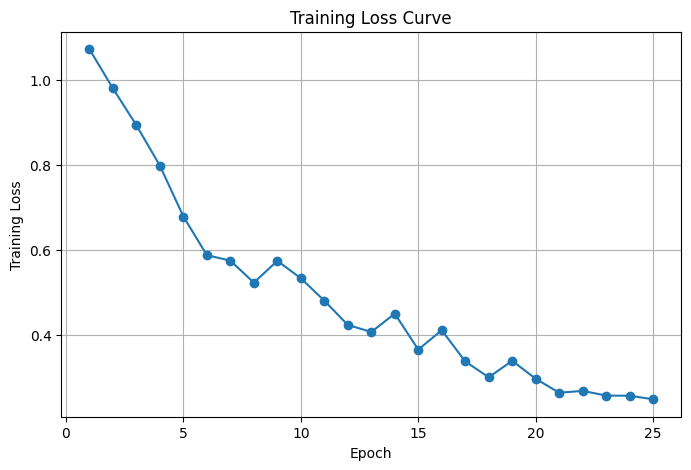

In [22]:
## Plot training loss curves

plt.figure(figsize=(8, 5))
plt.plot(range(1, custom_cnn_epochs + 1), custom_cnn_train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


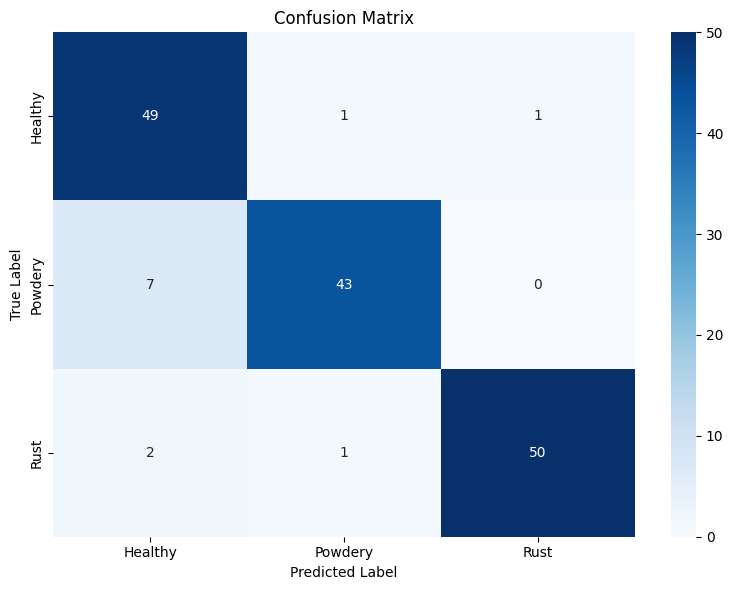

In [23]:
##Confusion Matrix
custom_cnn_confusion_matrix = confusion_matrix(custom_cnn_all_labels, custom_cnn_all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    custom_cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


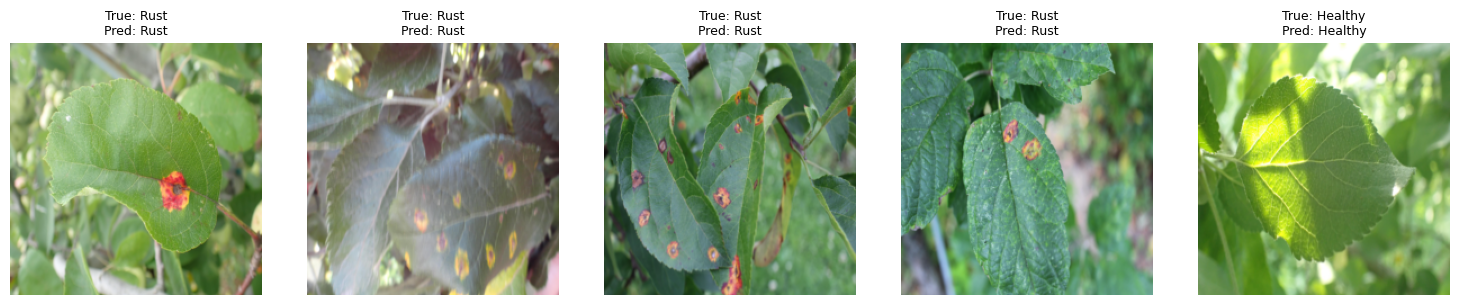

In [24]:
## Visualize some predictions
# Number of samples to display
num_samples = min(5, images.size(0))
class_names = train_dataset.classes

plt.figure(figsize=(15, 3))
for i in range(num_samples):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3.1 Load Pre-trained Model and Modify Architecture

In [25]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [26]:
# TODO: Choose and load pre-trained model
pretrained_model_name = "ResNet18"

In [27]:
from torchvision import models
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model
    
    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes
    
    Returns:
        model: compiled transfer learning model
    """
    # TODO: Load pre-trained model without top layers
    # TODO: Freeze base layers
    # TODO: Add Global Average Pooling + custom classification head
    # TODO: Compile model
    if base_model_name.lower() != "resnet18":
        raise ValueError("This function supports ResNet18 only")
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Freeze base layers
    for param in base_model.parameters():
        param.requires_grad = False
    in_features = base_model.fc.in_features
    base_model.fc = nn.Identity()
    #Custom classification head with GAP (MANDATORY)
    classification_head = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, n_classes)
    )
    class TransferLearningResNet18(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            x = self.backbone(x)
            x = self.head(x)
            return x

    model = TransferLearningResNet18(base_model, classification_head)

    return model


In [28]:
# TODO: Create transfer learning model
transfer_cnn = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes).to(device)

In [29]:
# REQUIRED: Count layers and parameters
frozen_layers = 0  # TODO: Count frozen layers
trainable_layers = 0  # TODO: Count trainable layers
total_parameters = 0  # TODO: Total parameters
trainable_parameters = 0  # TODO: Trainable parameters only

for name, param in transfer_cnn.named_parameters():
    # Count parameters
    num_params = param.numel()
    total_parameters += num_params

    if param.requires_grad:
        trainable_layers += 1
        trainable_parameters += num_params
    else:
        frozen_layers += 1

In [30]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet18
Frozen Layers: 60
Trainable Layers: 4
Total Parameters: 11,242,563
Trainable Parameters: 66,051
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [31]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [32]:
# Training configuration
transfer_cnn_learning_rate = 0.001
transfer_cnn_epochs = 10
transfer_cnn_batch_size = 32
transfer_cnn_optimizer = "Adam"

In [33]:
# Track training time
tl_start_time = time.time()

In [34]:
# TODO: Train model
# For Keras: history = transfer_model.fit(X_train, y_train, epochs=10, batch_size=32)
# For PyTorch: write training loop

criterion = torch.nn.CrossEntropyLoss()

# Only train parameters that require gradients (classification head)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, transfer_cnn.parameters()),
    transfer_cnn_learning_rate
)

tl_train_losses = []
tl_train_accuracies = []
tl_total = 0
tl_correct = 0

for epoch in range(transfer_cnn_epochs):
    transfer_cnn.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = transfer_cnn(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        tl_correct += (preds == labels).sum().item()
        tl_total += labels.size(0)

    epoch_loss = running_loss / tl_total
    epoch_acc = tl_correct / tl_total

    tl_train_losses.append(epoch_loss)
    tl_train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{transfer_cnn_epochs}] "f"- Loss: {epoch_loss:.4f} "f"- Accuracy: {epoch_acc:.4f}")


Epoch [1/10] - Loss: 0.0347 - Accuracy: 0.7837
Epoch [2/10] - Loss: 0.0101 - Accuracy: 0.8345
Epoch [3/10] - Loss: 0.0056 - Accuracy: 0.8582
Epoch [4/10] - Loss: 0.0037 - Accuracy: 0.8735
Epoch [5/10] - Loss: 0.0029 - Accuracy: 0.8826
Epoch [6/10] - Loss: 0.0020 - Accuracy: 0.8927
Epoch [7/10] - Loss: 0.0018 - Accuracy: 0.8977
Epoch [8/10] - Loss: 0.0017 - Accuracy: 0.9008
Epoch [9/10] - Loss: 0.0011 - Accuracy: 0.9059
Epoch [10/10] - Loss: 0.0011 - Accuracy: 0.9113


In [35]:
tl_training_time = time.time() - tl_start_time

In [36]:
# REQUIRED: Track initial and final loss
tl_initial_loss = tl_train_losses[0] # TODO: Get from training history (first epoch)
tl_final_loss = tl_train_losses[-1] # TODO: Get from training history (last epoch)

In [37]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 897.42 seconds
Initial Loss: 0.0347
Final Loss: 0.0011


### 3.3 Evaluate Transfer Learning Model
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [38]:
# REQUIRED: Calculate all 4 metrics
transfer_cnn.eval()  # Set model to evaluation mode

transfer_cnn_all_preds = []
transfer_cnn_all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = transfer_cnn(images)
        _, preds = torch.max(outputs, 1)

        transfer_cnn_all_preds.extend(preds.cpu().numpy())
        transfer_cnn_all_labels.extend(labels.cpu().numpy())
tl_accuracy = accuracy_score(transfer_cnn_all_labels, transfer_cnn_all_preds)
tl_precision = precision_score(transfer_cnn_all_labels, transfer_cnn_all_preds, average='macro')
tl_recall = recall_score(transfer_cnn_all_labels, transfer_cnn_all_preds, average='macro')
tl_f1 = f1_score(transfer_cnn_all_labels, transfer_cnn_all_preds, average='macro')

In [39]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.9610
Precision: 0.9625
Recall:    0.9613
F1-Score:  0.9615


### 3.4 Visualize Transfer Learning Results
- TODO: Plot training curves (loss and accuracy)
- TODO: Plot confusion matrix
- TODO: Show sample predictions

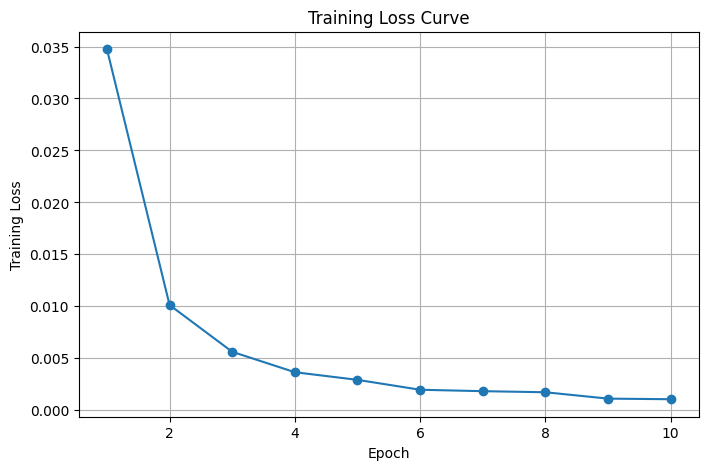

In [40]:
## Plot training loss curves

plt.figure(figsize=(8, 5))
plt.plot(range(1, transfer_cnn_epochs + 1), tl_train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


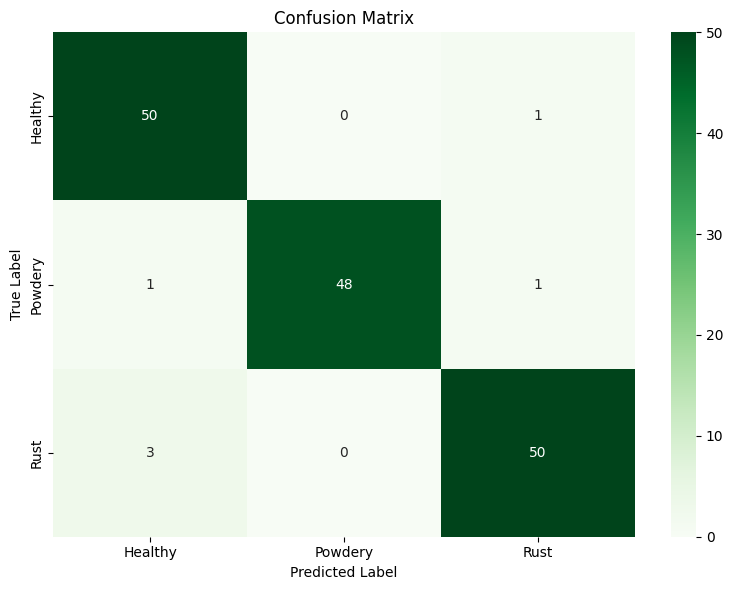

In [54]:
##Confusion Matrix
transfer_cnn_confusion_matrix = confusion_matrix(transfer_cnn_all_labels, transfer_cnn_all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    transfer_cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


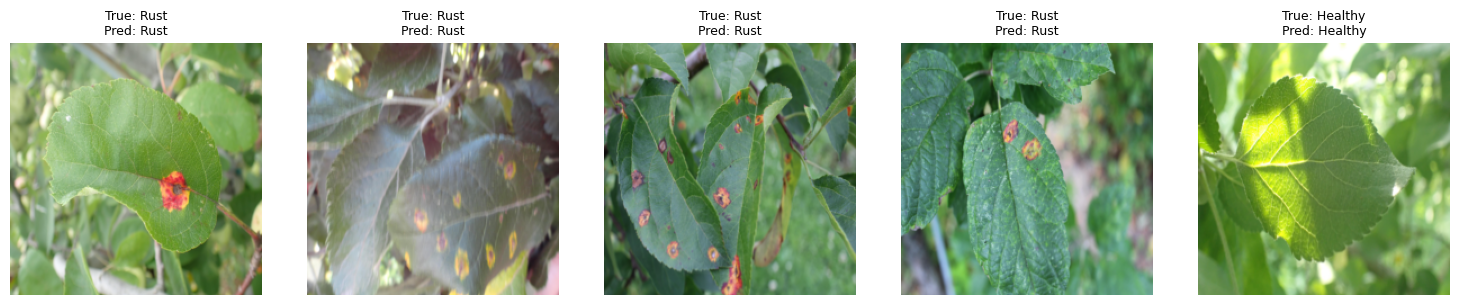

In [42]:
## Visualize some predictions
# Number of samples to display
num_samples = 5
num_samples = min(5, images.size(0))
class_names = train_dataset.classes

plt.figure(figsize=(15, 3))
for i in range(num_samples):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4.1 Metrics Comparison

In [43]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        sum(
    p.numel() for p in custom_cnn.parameters()
)  # TODO: Fill with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [44]:
print(comparison_df.to_string(index=False))

           Metric   Custom CNN  Transfer Learning
         Accuracy     0.922078           0.961039
        Precision     0.927434           0.962488
           Recall     0.922078           0.961263
         F1-Score     0.922584           0.961451
Training Time (s)  2262.525855         897.421007
       Parameters 93635.000000       66051.000000


### 4.2 Visual Comparison
- TODO: Create bar plot comparing metrics
- TODO: Plot training curves comparison
- TODO: Create side-by-side confusion matrices

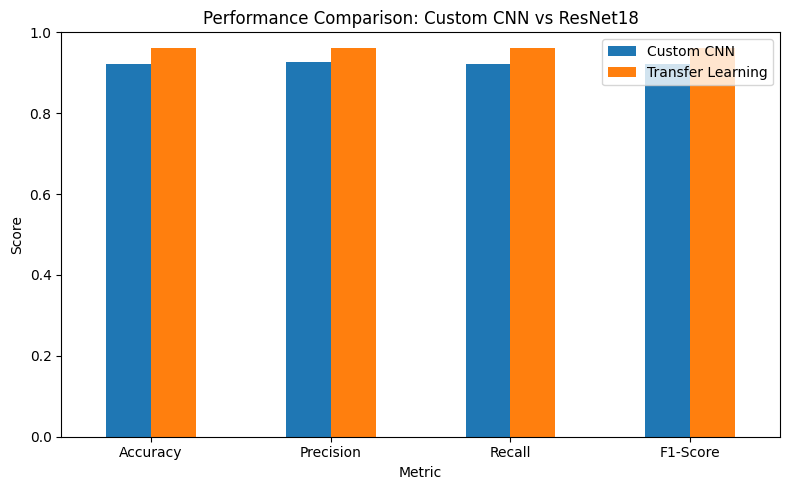

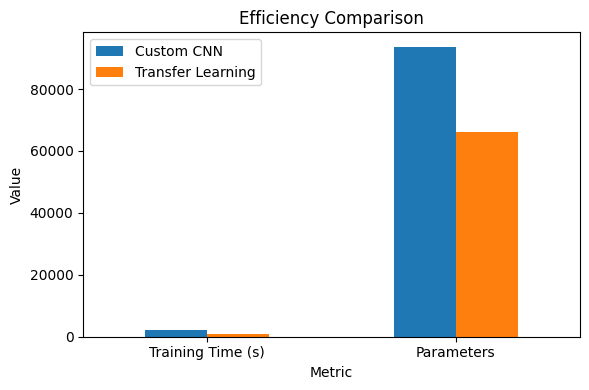

In [45]:
metrics_df = comparison_df.iloc[:4]  # Accuracy, Precision, Recall, F1

metrics_df.set_index("Metric").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Performance Comparison: Custom CNN vs ResNet18")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

parameter_df = comparison_df.iloc[4:]  # Training Time, Parameters

parameter_df.set_index("Metric").plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Efficiency Comparison")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



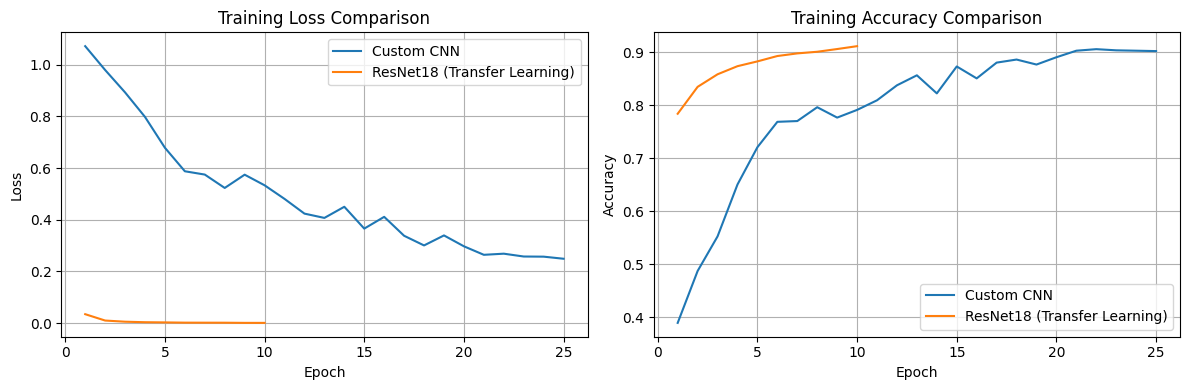

In [46]:
import matplotlib.pyplot as plt

epochs_custom = range(1, len(custom_cnn_train_losses) + 1)
epochs_tl = range(1, len(tl_train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_custom, custom_cnn_train_losses, label="Custom CNN")
plt.plot(epochs_tl, tl_train_losses, label="ResNet18 (Transfer Learning)")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_custom, custom_cnn_train_accuracies, label="Custom CNN")
plt.plot(epochs_tl, tl_train_accuracies, label="ResNet18 (Transfer Learning)")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



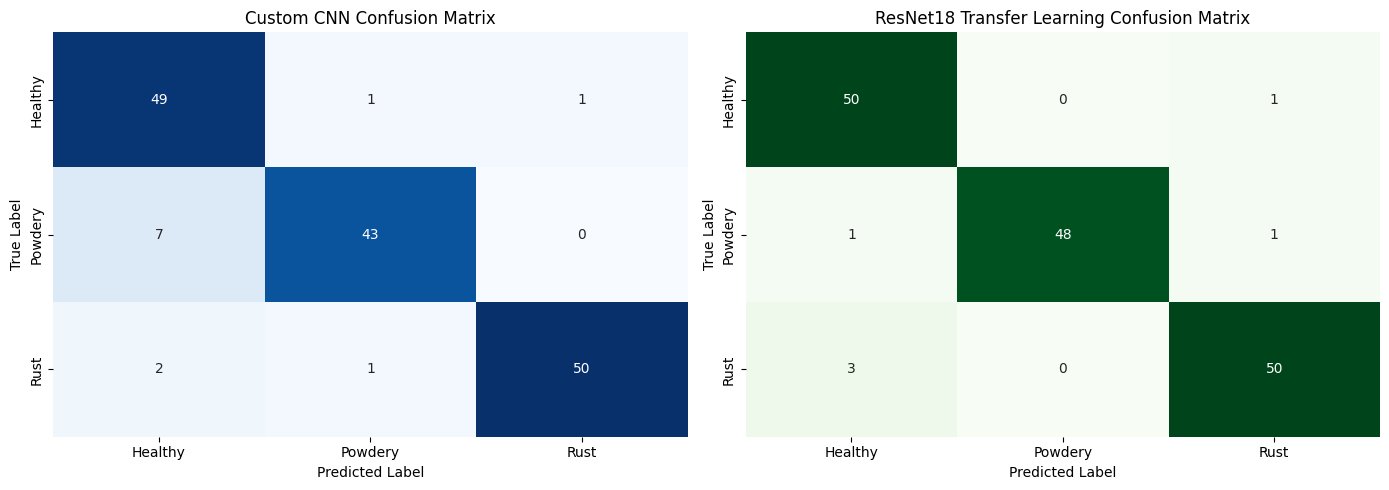

In [47]:
class_names = train_dataset.classes
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    custom_cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.subplot(1, 2, 2)
sns.heatmap(
    transfer_cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)
plt.title("ResNet18 Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


In [48]:
analysis_text = """
1. Which model performed better and by how much?
   The ResNet18-based transfer learning model demonstrated superior performance compared to the custom 
   CNN across all evaluation metrics, including accuracy, precision, recall, and F1-score. The improvement 
   in accuracy was notable, indicating enhanced generalization and more reliable class-wise predictions.

2. Impact of pre-training vs training from scratch?
   The custom CNN, trained entirely on the target dataset, required additional training to learn low-level 
   features, resulting in slower convergence and comparatively lower performance.
   
3. Effect of Global Average Pooling?
   Global Average Pooling design choice contributed to improved regularization and reduced overfitting, particularly 
   important given the limited dataset size.

4. Computational cost comparison?
   The transfer learning model was more efficient, requiring fewer trainable parameters and less training 
   time, whereas the custom CNN involved training all parameters from scratch leading to higher computational costs.

5. Insights about transfer learning?
   transfer learning is more effective for small to medium-sized datasets, while custom CNN architectures 
   are better suited for large datasets or highly specialized tasks.
"""

In [49]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

1. Which model performed better and by how much?
   The ResNet18-based transfer learning model demonstrated superior performance compared to the custom 
   CNN across all evaluation metrics, including accuracy, precision, recall, and F1-score. The improvement 
   in accuracy was notable, indicating enhanced generalization and more reliable class-wise predictions.

2. Impact of pre-training vs training from scratch?
   The custom CNN, trained entirely on the target dataset, required additional training to learn low-level 
   features, resulting in slower convergence and comparatively lower performance.

3. Effect of Global Average Pooling?
   Global Average Pooling design choice contributed to improved regularization and reduced overfitting, particularly 
   important given the limited dataset size.

4. Computational cost comparison?
   The transfer learning model was more efficient, requiring fewer trainable parameters and less training 
   time, whereas the custom CNN involv

In [50]:
def get_assignment_results():
    """
    Generate complete assignment results in required format
    
    Returns:
        dict: Complete results with all required fields
    """
    
    framework_used = "pytorch"  # TODO: Change to "pytorch" if using PyTorch
    
    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        
        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 3,  # TODO: Count your conv layers
                'pooling_layers': 3,  # TODO: Count your pooling layers
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': 0  # TODO: Calculate total parameters
            },
            'training_config': {
                'learning_rate': custom_cnn_learning_rate,  # TODO: Your actual learning rate
                'n_epochs': custom_cnn_epochs,  # TODO: Your actual epochs
                'batch_size': batch_size,  # TODO: Your actual batch size
                'optimizer': 'Adam',  # TODO: Your actual optimizer
                'loss_function': 'categorical_crossentropy'  # TODO: Your actual loss
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },
        
        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': transfer_cnn_learning_rate,
                'n_epochs': transfer_cnn_epochs,
                'batch_size': transfer_cnn_batch_size,
                'optimizer': transfer_cnn_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },
        
        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        
        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }
    
    return results

In [51]:
# Generate and print results
try:
    assignment_results = get_assignment_results() 
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
    
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")   

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Plant Disease Detection",
  "dataset_source": "kaggle: https://www.kaggle.com/code/vad13irt/plant-disease-classification/input",
  "n_samples": 1532,
  "n_classes": 3,
  "samples_per_class": "min: 500, max: 528, avg: 510.67",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "Accuracy",
  "metric_justification": "\nAccuracy is chosen as the primary evaluation metric for plant disease detection because \nthe dataset is balanced across disease classes, the cost of misclassification is similar\nacross categories, and the task involves multi-class classification where overall correctness\nis important. Precision, recall, and confusion matrix are additionally reported to analyze\ndisease-specific performance and ensure reliable detection.",
  "train_samples": 1378,
  "test_samples": 154,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "pytorch",
    "architecture": {
     

In [52]:
# Display system information
import platform
import sys
from datetime import datetime
current_time = datetime.now()

print("===== Assignment Timestamp =====")
print("Date:", current_time.strftime("%Y-%m-%d"))
print("Time:", current_time.strftime("%H:%M:%S"))

print("===== System Information =====")
print(f"OS: {platform.system()} {platform.release()}")
print(f"OS Version: {platform.version()}")
print(f"Machine: {platform.machine()}")
print(f"Processor: {platform.processor()}")
print(f"Python Version: {sys.version.split()[0]}")

print("\n===== PyTorch Information =====")
print(f"PyTorch Version: {torch.__version__}")

# Device info
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Compute Device: Apple MPS (GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Compute Device: CUDA (GPU)")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Compute Device: CPU")

print(f"Selected Device: {device}")


===== Assignment Timestamp =====
Date: 2026-02-02
Time: 17:22:02
===== System Information =====
OS: Darwin 25.0.0
OS Version: Darwin Kernel Version 25.0.0: Mon Aug 25 21:17:51 PDT 2025; root:xnu-12377.1.9~3/RELEASE_ARM64_T6020
Machine: arm64
Processor: arm
Python Version: 3.13.8

===== PyTorch Information =====
PyTorch Version: 2.10.0
Compute Device: Apple MPS (GPU)
Selected Device: mps


ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


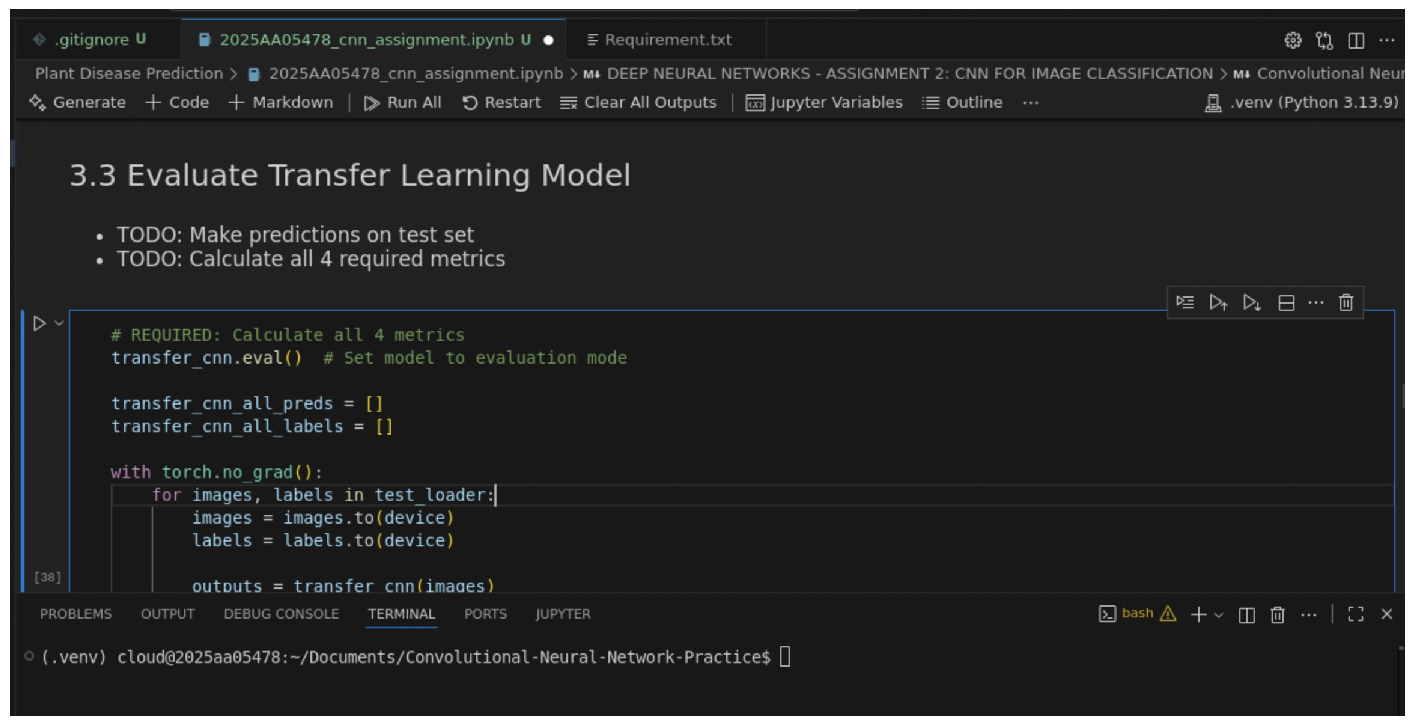

In [59]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here
image_path = "/Users/rishabhjain/Downloads/virtualLab_screenshot.jpg"
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)
plt.figure(figsize=(18, 18), dpi=100)
plt.imshow(img_np, interpolation="nearest")
plt.axis("off")
plt.show()